# Домашнее задание. Свёрточные сети

Здесь вам предстоит построить и обучить свою первую свёрточную сеть для классификации изображений на данных CIFAR10.

In [4]:
!pip install tensorflow

  Using cached tensorflow-2.19.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.0 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached grpcio-1.73.1-cp312-cp312-macosx_11_0_universal2.whl.metadata (3.8 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.10.0-py3-none-any.whl.metadata (6.0 kB)
  Using cached ml_dtypes-0.5.1-cp312-cp312-macosx_10_9_universal2.whl.metadata (21 kB)
  Using cached namex-0.1.0-py3-none-any.whl.me

In [15]:
import tensorflow as tf

from tqdm import tqdm_notebook ## визуализация прогресс-бара

## Данные

CIFAR10
* 60000 RGB изображений размером 32x32x3
* 10 классов: самолёты, собаки, рыбы и т.п.

<img src="https://www.samyzaf.com/ML/cifar10/cifar1.jpg" style="width:60%">

Загрузите данные, разделите их на обучающую и тестовую выборки. Размер тестовой выборки должен быть $10^4$.

In [146]:
import numpy as np
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=10**4, random_state=42)

class_names = np.array(['airplane','automobile ','bird ','cat ','deer ','dog ','frog ','horse ','ship ','truck'])

print (X_train.shape,y_train.shape)


(40000, 32, 32, 3) (40000, 1)


Прежде чем приступать к основной работе, стоит убедиться, что загружено именно то, что требовалось:

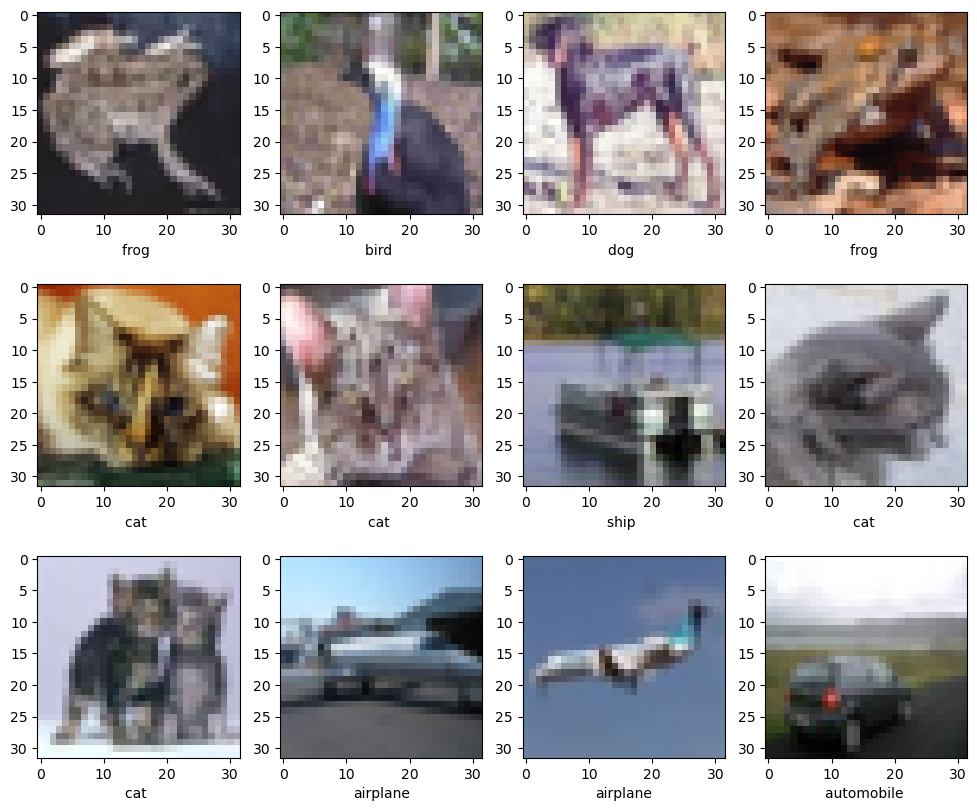

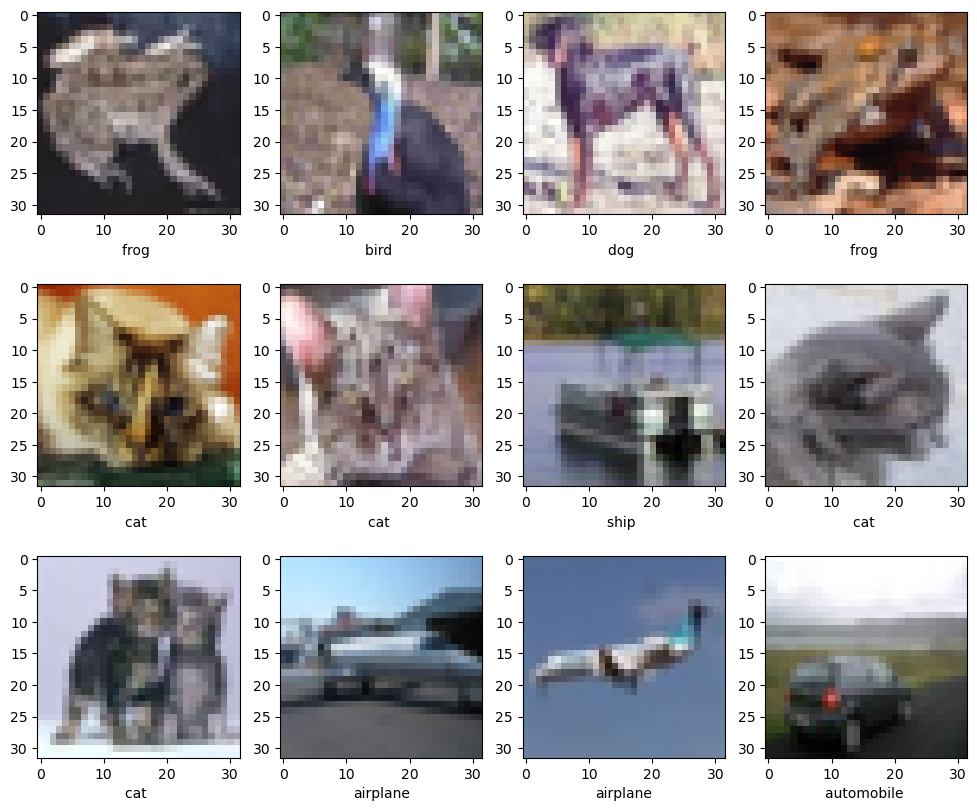

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3, 4, i + 1) ## 3 - количество строк, 4 - количество столбцов, i - номер ячейки, куда будет помещена картинка
    plt.xlabel(class_names[y_train[i, 0]])
    plt.imshow(X_train[i])
plt.show()

## Подготовка данных

Сейчас каждый пиксель изображения закодирован тройкой чисел (RGB) __от 0 до 255__. Однако лучше себя показывает подход, где значения входов нейросети распределены недалеко от 0.

Давайте приведём все данные в диапазон __`[0, 1]`__ — просто разделим на соответствующий коэффициент:

In [147]:
X_train = X_train / 255
X_val = X_val / 255
X_test = X_test / 255

Исполните код ниже для проверки, что все выполнено корректно.

Выдаст ошибку Assertion Error, если какое-то условие не выполнено

In [148]:
assert np.shape(X_train) == (40000, 32, 32, 3), "data shape should not change"
assert 0.9 <= max(map(np.max, (X_train, X_val, X_test))) <= 1.05
assert 0.0 <= min(map(np.min, (X_train, X_val, X_test))) <= 0.1
assert len(np.unique(X_test / 255.)) > 10, "make sure you casted data to float type"

## Архитектура сети

Для начала реализуйте простую нейросеть:
1. принимает на вход картинки размера 32 x 32 x 3;
2. вытягивает их в вектор (`keras.layers.Flatten`);
3. пропускает через 1 или 2 полносвязных слоя;
4. выходной слой отдает вероятности принадлежности к каждому из 10 классов.

Создайте полносвязную сеть:

In [71]:
import keras
from keras import layers as L
from keras import backend as K

In [72]:
model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(32, activation='relu', input_shape=X_train.shape[1:]), ## bs 32x32x3 - исключаем размер батча (количество картинок)
        tf.keras.layers.Flatten(), 
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')

])

In [73]:
dummy_pred = model.predict(X_train[:20])
assert dummy_pred.shape == (20, 10)
assert np.allclose(dummy_pred.sum(-1), 1) ## сумма всех вероятностей на последнем предсказании должна быть 1 
print("Успех!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Успех!


## Обучение сети

**Задание 1.1 (обязательно)** Будем минимизировать многоклассовую кроссэкнропию с помощью __sgd__. Вам нужно получить сеть, которая достигнет __не менее 45%__ __accuracy__ на тестовых данных.

__Важно:__ поскольку в y_train лежат номера классов, Керасу нужно либо указать sparse функции потерь и метрики оценки качества классификации (`sparse_categorical_crossentropy` и `sparse_categorical_accuracy`), либо конвертировать метки в one-hot формат.

### Полезные советы
* `model.compile` позволяет указать, какие метрики вы хотите вычислять.
* В `model.fit` можно передать валидационную выборку (`validation_data=[X_val, y_val]`), для отслеживания прогресса на ней. Также рекомендуем сохранять результаты в [tensorboard](https://keras.io/callbacks/#tensorboard) или [wandb](https://docs.wandb.ai/integrations/jupyter). **Важно: логи tensorboard не получится без боли посмотреть через colab.** Workaround: скачать логи и запустить tensorboard локально или помучаться [с этим](https://stackoverflow.com/questions/47818822/can-i-use-tensorboard-with-google-colab).
* По умолчанию сеть учится 1 эпоху. Совсем не факт, что вам этого хватит. Число эпох можно настроить в методе `fit` (`epochs`).
* Ещё у Кераса есть много [полезных callback-ов](https://keras.io/callbacks/), которые можно попробовать. Например, автоматическая остановка или подбор скорости обучения.

In [149]:
y_train, y_val = (keras.utils.to_categorical(y) for y in (y_train, y_val)) ## переводим в one-hot метки

In [75]:
## калбэк - сохранение результата модели после каждой итерации(в данном случае после каждой эпохи - 1 проход модели по всем примерам дата-сета)
callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.h5'), 
## Обратный вызов используется совместно с обучением, чтобы сохранить модель или весовые коэффициенты (в файле контрольных точек) через определенный интервал, чтобы модель или весовые коэффициенты можно было загрузить позже для продолжения обучения из сохраненного состояния.
             tf.keras.callbacks.TensorBoard(log_dir='./logs'),

             tf.keras.callbacks.EarlyStopping(patience=3)]

In [76]:
## TODO
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss="categorical_crossentropy", metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=16, epochs=15, callbacks=callbacks, validation_split=0.2)

Epoch 1/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2408 - loss: 2.0642

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.2409 - loss: 2.0641 - val_accuracy: 0.3465 - val_loss: 1.8030
Epoch 2/15
1994/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3719 - loss: 1.7536

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3719 - loss: 1.7535 - val_accuracy: 0.4174 - val_loss: 1.6368
Epoch 3/15
1999/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4329 - loss: 1.6019

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4329 - loss: 1.6018 - val_accuracy: 0.4521 - val_loss: 1.5636
Epoch 4/15
1998/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4552 - loss: 1.5293

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4552 - loss: 1.5293 - val_accuracy: 0.4521 - val_loss: 1.5352
Epoch 5/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4798 - loss: 1.4773

...

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5419 - loss: 1.3026 - val_accuracy: 0.4950 - val_loss: 1.4233
Epoch 10/15
1999/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5516 - loss: 1.2676

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5516 - loss: 1.2676 - val_accuracy: 0.5002 - val_loss: 1.4219
Epoch 11/15
1992/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5644 - loss: 1.2454

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5644 - loss: 1.2454 - val_accuracy: 0.5034 - val_loss: 1.4334
Epoch 12/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5776 - loss: 1.2013

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5776 - loss: 1.2013 - val_accuracy: 0.4936 - val_loss: 1.4559
Epoch 13/15
1993/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5900 - loss: 1.1682

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5900 - loss: 1.1682 - val_accuracy: 0.5082 - val_loss: 1.4220


А теперь можно проверить качество вашей сети, выполнив код ниже:

In [77]:
from sklearn.metrics import accuracy_score

predict_x=model.predict(X_test)
classes_x=np.argmax(predict_x,axis=1) ## для каждого объекта предсказанных выведется индекс, на месте которого стоит большая вероятность

test_acc = accuracy_score(y_test, classes_x) 
print("\n Test_acc =", test_acc)
assert test_acc > 0.45, "Not good enough. Back to the drawing board :)"
print(" Not bad!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

 Test_acc = 0.5116
 Not bad!


## Карманная сверточная сеть

**Задание 1.2 (обязательно)** Реализуйте небольшую свёрточную сеть. Совсем небольшую:
1. Входной слой
2. Свёртка 3x3 с 10 фильтрами
3. Нелинейность на ваш вкус
4. Max-pooling 2x2
5. Вытягиваем оставшееся в вектор (Flatten)
6. Полносвязный слой на 100 нейронов
7. Нелинейность на ваш вкус
8. Выходной полносвязный слой с softmax

Обучите её так же, как и предыдущую сеть. Если всё хорошо, у вас получится accuracy не меньше __50%__.

In [78]:
## TODO
new_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10, kernel_size=(3, 3), padding='same', activation='relu',input_shape=X_train.shape[1:]), ## bs 32,32,3
    tf.keras.layers.MaxPool2D(pool_size=(2,2),padding='valid'), ## берем максимальные значения из карты признаков и уменьшаем ее в два раза
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')


])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
new_callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath='new_model.{epoch:02d}-{val_loss:.2f}.h5'),
             tf.keras.callbacks.TensorBoard(log_dir='./logs'),
             tf.keras.callbacks.EarlyStopping(patience=3)]

In [80]:
## TODO
new_model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss="categorical_crossentropy", metrics=['accuracy'])
new_model.fit(X_train, y_train, batch_size=16, epochs=15, callbacks=new_callbacks, validation_split=0.2)

Epoch 1/15
1998/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2671 - loss: 2.0172

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2672 - loss: 2.0170 - val_accuracy: 0.3913 - val_loss: 1.7118
Epoch 2/15
1988/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4313 - loss: 1.6010

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4314 - loss: 1.6008 - val_accuracy: 0.4541 - val_loss: 1.5299
Epoch 3/15
1995/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4821 - loss: 1.4571

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4822 - loss: 1.4570 - val_accuracy: 0.4824 - val_loss: 1.4356
Epoch 4/15
1995/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5222 - loss: 1.3447

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5222 - loss: 1.3447 - val_accuracy: 0.5296 - val_loss: 1.3241
Epoch 5/15
1994/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5541 - loss: 1.2623

...

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6616 - loss: 0.9657 - val_accuracy: 0.5849 - val_loss: 1.2017
Epoch 12/15
1991/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6828 - loss: 0.9104

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6828 - loss: 0.9104 - val_accuracy: 0.5832 - val_loss: 1.2023
Epoch 13/15
1995/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6903 - loss: 0.8779

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6903 - loss: 0.8779 - val_accuracy: 0.5989 - val_loss: 1.1710
Epoch 14/15
1995/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7105 - loss: 0.8349

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7105 - loss: 0.8349 - val_accuracy: 0.6060 - val_loss: 1.1799
Epoch 15/15
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7244 - loss: 0.7846

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7244 - loss: 0.7846 - val_accuracy: 0.5840 - val_loss: 1.2279


Давайте посмотрим, смогла ли карманная сверточная сеть побить заданный порог по качеству:

In [81]:
from sklearn.metrics import accuracy_score

predict_x = new_model.predict(X_test)
classes_x = np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
assert test_acc > 0.50, "Not good enough. Back to the drawing board :)"
print(" Not bad!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

 Test_acc = 0.5908
 Not bad!


## Учимся учить

А теперь научимся сравнивать кривые обучения моделей — зависимости значения accuracy от количества итераций.

Вам потребуется реализовать _экспериментальный стенд_ — вспомогательный код, в который вы сможете подать несколько архитектур и методов обучения, чтобы он их обучил и вывел графики кривых обучения. Это можно сделать с помощью `keras.callbacks` — `TensorBoard` или `History`.

Будьте морально готовы, что на обучение уйдёт _много времени_. Даже если вы ограничитесь 10 эпохами. Пока идёт обучение, вы можете переключиться на другие задания или заняться чем-нибудь приятным: поспать, например.

**Задание 1.3 (опционально)** Попробуйте использовать различные методы оптимизации (sgd, momentum, adam) с параметрами по умолчанию. Какой из методов работает лучше?

Для удобства напишем класс Evaluator, который принимает в себя дикты виды {имя_оптимайзера: инстанс}, {имя модели: инстанс} и обучает всевозможные комбинации моделей с оптимайзерами при помощи метода fit (попутно записывая логи отдельно для каждой модели). Также пригодится метод evaluate для отображения итоговых скоров.

Пользоваться классом не обязательно. По умолчанию класс использует tensorboard. Если вы выше использовали wandb -- советуем дописать callback.

In [82]:
class Evaluator(list):
    def __init__(self, models, optimizers='adam', loss=keras.losses.categorical_crossentropy,
                 metrics=[keras.metrics.categorical_accuracy]):
        '''
            models: dict {name: model}
            optimizers: list of optimizers or just one optimizer
        '''
        if not isinstance(models, dict): ## преобразование в словарь
            models = {'single_model': models}
        if not isinstance(optimizers, dict): ## преобразование в словарь
            optimizers = {str(optimizers.__class__): optimizers}

        super().__init__([(model_name, keras.models.clone_model(model), optimizer_name, optimizer)
                           ## наследуем класс init, перебираем все модели из списка моделей и все оптимизаторы из списка оптимизаторов
                           ## keras.models.clone_model(model) создаем клон модели, чтобы оптимизаторы не мешали друг другу
                          for model_name, model in models.items()
                          for optimizer_name, optimizer in optimizers.items()])
        for _, model, _, optimizer in self: ## берем только переменные model и optimizator, с помощбю заглушки _ глушим остальные переменные
            model.compile(optimizer=optimizer, loss=loss, metrics=metrics) ## компилируем модель из заданного оптимизатора, установленной ошибки категориальной кросс-энтропии и метрик из библиотеки keras

    def fit(self, X, y, validation_data=(), max_epochs=100, verbose=0, callbacks=[], batch_size=32):
        if not isinstance(callbacks, list): ## если колбэки это не список, то помещаем их в список
            callbacks = [callbacks]
        for model_name, model, optimizer_name, optimizer in tqdm_notebook(self): 
            model.fit(X, y, validation_data=validation_data or None, epochs=max_epochs, verbose=verbose, ## обучаем модель
                      ## verbose = 0 - не выводим информацию в консоль во время обучения
                      batch_size=batch_size, callbacks=callbacks + [keras.callbacks.TensorBoard(
                          log_dir='./logs/{}_{}'.format(model_name, optimizer_name))])
            ## callback TensorBoard сохраняет в папку ./logs/model_optimizer логи, которые являются интерфейсом с графиками кривых обучения с разными оптимизаторами

## проводим аугментацию изображений - увеличения выборки данных через модификацию существующих данных
    def fit_generator(self, X, y, validation_data=(), max_epochs=100, verbose=1, callbacks=[], batch_size=32):
        datagen = keras.preprocessing.image.ImageDataGenerator(
            rotation_range=20, ## поворот картинки на угол от -20 до +20
            width_shift_range=0.2, ## случайный сдвиг по ширине на 20 процентов от общей ширины картинки
            height_shift_range=0.2, ## по высоте
            horizontal_flip=True ## отзеркаливание
        )
        if not isinstance(callbacks, list):
            callbacks = [callbacks]
        for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):
            model.fit_generator(datagen.flow(X, y, batch_size=batch_size), epochs=max_epochs, ## для каждой модели применяем аугментацию, предварительно указав, что модель будет обучаться по батчам (метод fit_generation)
                validation_data=validation_data or None, verbose=verbose,
                callbacks=callbacks + [keras.callbacks.TensorBoard(
                    log_dir='./logs/{}_{}'.format(model_name, optimizer_name))])

    def evaluate(self, X, y, metric):
        for model_name, model, optimizer_name, _ in self:
            print('Final score of {}_{} is {}'.format(model_name, optimizer_name,
                  metric(y_test, model.predict(X_test).argmax(axis=1)))) ## получаем финальные метрики для самой большой предсказанной вероятности

In [83]:
!rm -rf ./logs

In [87]:
from tensorflow.keras import optimizers

## TODO
optimizers = {"SGD": keras.optimizers.SGD(),
    "Adam": keras.optimizers.Adam(),
    "RMSprop": keras.optimizers.RMSprop()
}

In [88]:
evaluator = Evaluator(model, optimizers=optimizers)
evaluator.fit(X_train, y_train, validation_data=(X_val, y_val))
evaluator.evaluate(X_test, y_test, accuracy_score)

/var/folders/07/xx2bf7ss4g30z8mzlm1lcbqr0000gn/T/ipykernel_9499/2505868840.py:21: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):


  0%|          | 0/3 [00:00<?, ?it/s]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Final score of single_model_SGD is 0.4684
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Final score of single_model_Adam is 0.4058
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Final score of single_model_RMSprop is 0.4089


In [89]:
!pwd

/Users/sofagusina/Downloads


In [91]:
!ls logs/
!ls logs/model_1

single_model_Adam    single_model_RMSprop single_model_SGD
ls: logs/model_1: No such file or directory


In [94]:
%tensorboard --logdir logs

Reusing TensorBoard on port 6006 (pid 11494), started 0:03:04 ago. (Use '!kill 11494' to kill it.)

Прокомментируйте полученные результаты.

Можно сделать вывод, что модели с разными оптимизаторами начинают переобучаться после 20-30 тысяч итераций или после 20-30 эпохи. Однаку самоую высокую точность показала модель с оптимизатором SGD: пиковая accuracy - 55 процентов, финальная - 46 процентов. Раньше всех начала переобучаться модель с оптимизатором RMSProp и показала самую низкую финальную accuracy - 40 процентов.

**Задание 1.4 (опционально)** Добавьте нормализацию по батчу (`BatchNormalization`) между свёрткой и активацией. Попробуйте использовать несколько нормализаций — в свёрточных и полносвязных слоях.

Для удобства реализуем класс Models, который по сути будет являться списком моделей с двумя методами: add (добавить слой ко всем моделям) и add_create (создать новую модель на основе базовой с дополнительным слоем). Пользоваться им необязательно, но вдруг :)

In [96]:
from collections import OrderedDict

class Models(OrderedDict):
    def __init__(self, models):
        if not isinstance(models, dict):
            models = OrderedDict({'base_model': models})
        super().__init__(models)

    def add(self, layer):
        for name, model in self.items():
            model.add(layer)

    def add_create(self, name, layer):
        base_model = next(iter(self.items()))[1]
        new_model = keras.models.clone_model(base_model)
        new_model.add(layer)
        self.update({name: new_model})

    def add_update(self, name, layer):
        base_model = self[next(reversed(self))]
        new_model = keras.models.clone_model(base_model)
        new_model.add(layer)
        self.update({name: new_model})

# Example of usage
# models = Models(keras.Sequential())
# models.add(L.InputLayer(input_shape=(32, 32, 3)))
# models.add(L.Convolution2D(filters=10, kernel_size=(3, 3)))
# models.add(L.MaxPooling2D())
# models.add_create('conv_batchnorm', L.BatchNormalization())
# models.add(L.Activation('relu'))
# ...

In [106]:

models = Models(keras.Sequential())
models.add(L.InputLayer(input_shape=X_train.shape[1:]))
models.add(L.Convolution2D(filters=10, kernel_size=(3, 3), padding='same', activation='relu',input_shape=X_train.shape[1:]))
models.add(L.MaxPooling2D(pool_size=(2,2),padding='valid'))
models.add_create('conv_batchnorm', L.BatchNormalization())

models.add(L.Activation('relu'))
models.add(L.Flatten())
models.add(L.Dense(100, activation='relu'))
models.add(L.Dense(10, activation='softmax'))



In [123]:
models['base_model'].compile(optimizer='SGD',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [131]:
## задание 1.6 случайно оказалось тут 
batch_sizes = [3, 5, 10, 25, 50]
optimizers = {"SGD": keras.optimizers.SGD(),
    "Adam": keras.optimizers.Adam(),
    "RMSprop": keras.optimizers.RMSprop()
}
for optimizer_name,optimizer in optimizers.items():
    models['base_model'].compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    for bs in batch_sizes:
        callback = [keras.callbacks.TensorBoard(log_dir=f'./logs/model_bs_{bs}_optimazer{optimizer_name}')]
        print(f"Training with batch size = {bs}")
        models['base_model'].fit(
         X_train, y_train,
            batch_size=bs,
            epochs=8,
            callbacks=callback,
            validation_data=(X_val, y_val)
        )


Training with batch size = 3
Epoch 1/8
13334/13334 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - accuracy: 0.9998 - loss: 0.0026 - val_accuracy: 0.5900 - val_loss: 4.6843
Epoch 2/8
13334/13334 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - accuracy: 0.9998 - loss: 0.0030 - val_accuracy: 0.5907 - val_loss: 4.7137
Epoch 3/8
13334/13334 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.5909 - val_loss: 4.7587
Epoch 4/8
13334/13334 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - accuracy: 0.9999 - loss: 0.0018 - val_accuracy: 0.5919 - val_loss: 4.8010
Epoch 5/8
13334/13334 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.5922 - val_loss: 4.8473
Epoch 6/8
13334/13334 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.5914 - val_loss: 4.8873
Epoch 7/8
13334/13334 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.5922 - val_loss: 4.9230
Epoch 8/8
13334/13334 ━━━━━━━━━━━━━━━━━━━━ 30s 

Прокомментируйте полученные результаты.

Если сравнивать две модели - без батч нормализации данных и с батч нормализацией, то модели на последней для второй модели эпохе (10) показали одинаковые значения точности, однако модель с нормализацией "быстрее" достигала этого значения - ее метрика accuracy на промежуточных эпохах выше, чем у модели без нормализации. Нормализация позволяет бороться с затуханием или взрывом градиентов и ускорять процесс обучение, вторая задача нормализации как раз отражена практически в ходе обучения. Данные передаются в модель батчами, и находится среднее значение по батчу, стандартное отклонение и происходит нормализация выхода слоя, который потом подается в слой активации

**Задание 1.5 (опционально)** Посмотрите на batch_size (параметр model.fit) - при большем батче модель будет быстрее проходить эпохи, но с совсем огромным батчом вам потребуется больше эпох для сходимости (т.к. сеть делает меньше шагов за одну эпоху).
Найдите такое значение, при котором модель быстрее достигает точности 55%. **Hint**: используйте early stopping callback.

In [120]:
models['base_model'].fit(X_train, y_train, batch_size=5, epochs=5, callbacks=new_callbacks, validation_split=0.2,validation_data=(X_val, y_val))

Epoch 1/5
7987/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9559 - loss: 0.1417

8000/8000 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9559 - loss: 0.1418 - val_accuracy: 0.5772 - val_loss: 2.4053
Epoch 2/5
7999/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9183 - loss: 0.2257

8000/8000 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9183 - loss: 0.2257 - val_accuracy: 0.5780 - val_loss: 2.4104
Epoch 3/5
7989/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9314 - loss: 0.1959

8000/8000 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9313 - loss: 0.1960 - val_accuracy: 0.5858 - val_loss: 2.3939
Epoch 4/5
7992/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9473 - loss: 0.1585

8000/8000 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9473 - loss: 0.1585 - val_accuracy: 0.5840 - val_loss: 2.5079
Epoch 5/5
7993/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9534 - loss: 0.1354

8000/8000 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9534 - loss: 0.1354 - val_accuracy: 0.5817 - val_loss: 2.6343


Время достижения accuracy в 55 процентов на валидационной выборке 
1) Для bs = 3  34 секунд
2) Для bs = 5 - 28 секунд 
3) Для bs = 10 - 16 секунд
4) Для bs = 20 - 10 секунд
4) Для bs = 50 - 10 секунд 
5) ля bs = 100 - 6 секунд  

Лучше всего показала себя модель с bs = 5, так как при достаточно высоком времени по сравнению с остальными моделями, она демонстрировала несущественное изменение точности, что можно интерпретировать как хорошую сходимость модели

**Задание 1.6 (опционально)** Попробуйте найти такую комбинацию метода обучения и нормализации, при которой сеть имеет наилучшую кривую обучения. Поясните, что вы понимаете под "наилучшей" кривой обучения.

In [132]:
!ls logs/

model_bs_1                   model_bs_5
model_bs_10                  model_bs_50
model_bs_10_optimazerAdam    model_bs_50_optimazerAdam
model_bs_10_optimazerRMSprop model_bs_50_optimazerRMSprop
model_bs_10_optimazerSGD     model_bs_50_optimazerSGD
model_bs_25                  model_bs_5_optimazerAdam
model_bs_25_optimazerAdam    model_bs_5_optimazerRMSprop
model_bs_25_optimazerRMSprop model_bs_5_optimazerSGD
model_bs_25_optimazerSGD     single_model_Adam
model_bs_3                   single_model_RMSprop
model_bs_3_optimazerAdam     single_model_SGD
model_bs_3_optimazerRMSprop  train
model_bs_3_optimazerSGD      validation


In [133]:
%tensorboard --logdir logs

Reusing TensorBoard on port 6006 (pid 11494), started 1:50:25 ago. (Use '!kill 11494' to kill it.)

Быстрее всего до accuracy на валидационной выборке в 55 процентов доходят модель с оптимизацией SGD и размером батча в 25 примеров и модель с оптимизацией Adam с размером батча, равном 10. Однако первая модель имеет достаточно высокую ошибку на валидационной выборке, которая по мере увеличения итераций растет, в отличие от второй модели. Поэтому в качестве лучшей модели с точки зрения кривой обучения выберем модель с оптимизацией Adam и batchsize=10.

## Свёрточная нейросеть здорового человека

**Задание 1.7 (обязательно попытаться)** Наигравшись выше, обучим большую свёрточную сеть, которая даст на тестовой выборке __accuracy больше 80%__. В этом задании вам потребуется провести эксперименты, сравнив их между собой в конце. Возможно, может быть несколько проще, если писать выводы во время или сразу после каждого эксперимента, после чего сделать общие выводы.

Рекомендуем начать с лучшей модели предыдущего задания и постепенно её улучшать. Вы можете использовать всё, что угодно: любые активации, сколь угодно большие свёрточные слои и глубокие сети. Единственное ограничение: __нельзя использовать предобученные сети и дополнительные данные__.

### Полезные советы
* Для начала, неплохо бы научить что-нибудь побольше, чем 10 фильтров 3x3.
* __Главное правило: одно изменение на эксперимент__. Если у вас есть 2 идеи по улучшению сети, сначала попробуйте их независимо. Может оказаться, что одно из них дало __+10%__ точности а другое __-7%__. А вы так и будете думать, что сделали 2 полезных изменения которые в сумме дают __+3%__. Если какая-то идея не работает — даже если она вам нравится - опишите ее и выкидывайте из дальнейших экспериментов.
* __Be careful or you will dropout__. Дропаут (`L.Dropout`) может позволить вам обучить в несколько раз бОльшую сеть без переобучения, выжав несколько процентов качества. Это круто, но не стоит сразу ставить dropout 50%. Во-первых, слишком сильный дропаут только ухудшит сеть (underfitting). Во-вторых, даже если дропаут улучшает качество, он замедляет обучение. Рекомендуем начинать с небольшого дропаута, быстро провести основные эксперименты, а потом жахнуть в 2 раза больше нейронов и дропаута ~~на ночь~~.
* __Аугментация данных__. Если котика слегка повернуть и подрезать (простите), он всё равно останется котиком. А в керасе есть [удобный класс](https://keras.io/preprocessing/image/), который поставит подрезание котиков на поток. Ещё можно сделать этот трюк в тесте: вертим картинку 10 раз, предсказываем вероятности и усредняем. Только один совет: прежде, чем учить, посмотрите глазами на аугментированные картинки. Если вы сами не можете их различить, то и сеть не сможет.
* __Don't just stack more layers__. Есть более эффективные способы организовать слои, чем простой Sequential. Вот пара идей: [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions](https://arxiv.org/abs/1608.06993). Только не копируйте архитектуру подчистую — вам скорее всего хватит меньшего размера.
* __Долго != плохо__. Более глубокие архитектуры обычно требуют бОльше эпох до сходимости. Это значит, что в первые несколько эпох они могут быть хуже менее глубоких аналогов. Дайте им время, запаситесь чаем и обмажьтесь batch-norm-ом.

In [150]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

In [158]:
val_datagen = ImageDataGenerator()

split = 35000
dg_x_train, dg_x_val = X_train[:split], X_train[split:]
dg_y_train, dg_y_val = y_train[:split], y_train[split:]

In [152]:
## TODO
final_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=8, kernel_size=(3, 3), padding='same', activation='relu',input_shape=dg_x_train.shape[1:]), ## bs 32,32,6
    tf.keras.layers.MaxPool2D(pool_size=(2,2),padding='valid'), ## берем максимальные значения из карты признаков и уменьшаем ее в два раза ## bs 16,16,3
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu'), ## bs 16,16,16
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'), ## 8,8,16
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [153]:
final_callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.h5'),
                   tf.keras.callbacks.EarlyStopping(patience=5),]

In [154]:
tf.keras.utils.plot_model(final_model, '123.png', show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [160]:
print("dg_y_train shape:", dg_y_train.shape)
print("dg_y_val shape:", dg_y_val.shape)

dg_y_train shape: (35000, 10)
dg_y_val shape: (5000, 10)


In [159]:
X_train.shape

(40000, 32, 32, 3)

In [161]:
## TODO
final_model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
final_model.fit(datagen.flow(dg_x_train, dg_y_train, batch_size=16), epochs=20, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/20


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2182/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3436 - loss: 1.8244

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.3437 - loss: 1.8242 - val_accuracy: 0.4072 - val_loss: 1.6941
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3980 - loss: 1.6608

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.3980 - loss: 1.6608 - val_accuracy: 0.4596 - val_loss: 1.5113
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4419 - loss: 1.5566

...

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.5752 - loss: 1.1971 - val_accuracy: 0.6204 - val_loss: 1.1004
Epoch 17/20
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5809 - loss: 1.1746

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.5809 - loss: 1.1746 - val_accuracy: 0.6074 - val_loss: 1.1266
Epoch 18/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5852 - loss: 1.1665

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.5852 - loss: 1.1665 - val_accuracy: 0.6148 - val_loss: 1.0910
Epoch 19/20
2184/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5896 - loss: 1.1467

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.5896 - loss: 1.1467 - val_accuracy: 0.5986 - val_loss: 1.1237
Epoch 20/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5976 - loss: 1.1434

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.5976 - loss: 1.1434 - val_accuracy: 0.6280 - val_loss: 1.0544


Момент истины: проверьте, какого качества достигла ваша сеть.

In [162]:
from sklearn.metrics import accuracy_score

predict_x=final_model.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
if test_acc > 0.8:
    print("Это победа!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

 Test_acc = 0.6237


Данная модель показывает достаточно низкую accuracy на тестовой выборке, но не переобучается, что видно по характеристикам на валидационной выборке
Возможно, обучение происходило мало эпох, попробуем увеличить количество эпох до 36, как указано было первоначально

In [163]:
final_model.fit(datagen.flow(dg_x_train, dg_y_train, batch_size=16), epochs=36, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/36


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5959 - loss: 1.1325

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.5959 - loss: 1.1325 - val_accuracy: 0.6170 - val_loss: 1.0993
Epoch 2/36
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6066 - loss: 1.1220

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.6066 - loss: 1.1220 - val_accuracy: 0.5992 - val_loss: 1.1488
Epoch 3/36
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6033 - loss: 1.1210

...

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.6185 - loss: 1.0683 - val_accuracy: 0.6406 - val_loss: 1.0430
Epoch 11/36
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6202 - loss: 1.0701

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.6202 - loss: 1.0701 - val_accuracy: 0.6422 - val_loss: 1.0328
Epoch 12/36
2184/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6223 - loss: 1.0691

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.6223 - loss: 1.0691 - val_accuracy: 0.6326 - val_loss: 1.0670
Epoch 13/36
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6204 - loss: 1.0588

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6204 - loss: 1.0588 - val_accuracy: 0.6450 - val_loss: 1.0153
Epoch 14/36
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6234 - loss: 1.0623

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.6234 - loss: 1.0623 - val_accuracy: 0.6410 - val_loss: 1.0313


Метрики валидации не улучшаются 5 эпох, поэтому модель остановила обучение после 14 эпохи, следовательно, дело не в количестве эпох. Посмотрим, как улучшатся метрики после добавления батч нормализации

In [168]:
final_model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=8, kernel_size=(3, 3), padding='same',input_shape=dg_x_train.shape[1:]), ## bs 32,32,6
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2),padding='valid'), ## берем максимальные значения из карты признаков и уменьшаем ее в два раза ## bs 16,16,3
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), padding='same'), ## bs 16,16,16
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'), ## 8,8,16
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [169]:
final_model_1.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
final_model_1.fit(datagen.flow(dg_x_train, dg_y_train, batch_size=16), epochs=20, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/20


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2779 - loss: 1.9526

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.2779 - loss: 1.9524 - val_accuracy: 0.4534 - val_loss: 1.4909
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4308 - loss: 1.5537

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.4308 - loss: 1.5537 - val_accuracy: 0.4470 - val_loss: 1.5673
Epoch 3/20
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4715 - loss: 1.4558

...

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.5983 - loss: 1.1487 - val_accuracy: 0.5362 - val_loss: 1.4003
Epoch 17/20
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5986 - loss: 1.1351

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.5986 - loss: 1.1351 - val_accuracy: 0.5794 - val_loss: 1.2516
Epoch 18/20
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6008 - loss: 1.1287

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6008 - loss: 1.1287 - val_accuracy: 0.6334 - val_loss: 1.0583
Epoch 19/20
2183/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6074 - loss: 1.1182

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6074 - loss: 1.1182 - val_accuracy: 0.6008 - val_loss: 1.1673
Epoch 20/20
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6077 - loss: 1.1155

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.6077 - loss: 1.1155 - val_accuracy: 0.6112 - val_loss: 1.1608


In [170]:
predict_x=final_model_1.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
if test_acc > 0.8:
    print("Это победа!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

 Test_acc = 0.6078


Метрика упала, попробуем уменьшить скорость обучения

In [172]:
final_model_1.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
final_model_1.fit(datagen.flow(dg_x_train, dg_y_train, batch_size=16), epochs=20, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/20
2183/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6351 - loss: 1.0388

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.6351 - loss: 1.0388 - val_accuracy: 0.6500 - val_loss: 1.0460
Epoch 2/20
2182/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6350 - loss: 1.0386

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6350 - loss: 1.0386 - val_accuracy: 0.6368 - val_loss: 1.0757
Epoch 3/20
2182/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6358 - loss: 1.0370

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.6358 - loss: 1.0370 - val_accuracy: 0.6436 - val_loss: 1.0572
Epoch 4/20
2183/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6326 - loss: 1.0504

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6326 - loss: 1.0503 - val_accuracy: 0.6456 - val_loss: 1.0605
Epoch 5/20
2183/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6350 - loss: 1.0363

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.6350 - loss: 1.0363 - val_accuracy: 0.6444 - val_loss: 1.0636
Epoch 6/20
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6356 - loss: 1.0402

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6356 - loss: 1.0403 - val_accuracy: 0.6376 - val_loss: 1.0839


Модель останаливается после 6 итерации, значит, скорость обучения слишком маленькая. Попробуем обучить модель без аугментации

In [173]:
final_model_1.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
final_model_1.fit(dg_x_train,dg_y_train, epochs=20, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/20
1091/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6716 - loss: 0.9315

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.6716 - loss: 0.9314 - val_accuracy: 0.6510 - val_loss: 1.0128
Epoch 2/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6848 - loss: 0.9025

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6848 - loss: 0.9025 - val_accuracy: 0.6686 - val_loss: 0.9503
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6876 - loss: 0.8877

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.6877 - loss: 0.8877 - val_accuracy: 0.6556 - val_loss: 0.9745
Epoch 4/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6972 - loss: 0.8666

...

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7225 - loss: 0.7985 - val_accuracy: 0.6758 - val_loss: 0.9535
Epoch 10/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7222 - loss: 0.7963

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7222 - loss: 0.7963 - val_accuracy: 0.6676 - val_loss: 0.9694
Epoch 11/20
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7308 - loss: 0.7755

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7308 - loss: 0.7755 - val_accuracy: 0.6702 - val_loss: 0.9644
Epoch 12/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7300 - loss: 0.7674

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7300 - loss: 0.7675 - val_accuracy: 0.6650 - val_loss: 0.9961
Epoch 13/20
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7349 - loss: 0.7566

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7349 - loss: 0.7566 - val_accuracy: 0.6498 - val_loss: 1.0415


In [174]:
predict_x=final_model_1.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
if test_acc > 0.8:
    print("Это победа!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

 Test_acc = 0.6478


Метрики увеличились, попробуем изменить оптимизатор на Adam

In [175]:
final_model_1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
final_model_1.fit(dg_x_train,dg_y_train, epochs=20, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/20
1091/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5149 - loss: 1.4091

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.5150 - loss: 1.4086 - val_accuracy: 0.4000 - val_loss: 1.7803
Epoch 2/20
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6053 - loss: 1.1334

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.6053 - loss: 1.1334 - val_accuracy: 0.5756 - val_loss: 1.2346
Epoch 3/20
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6344 - loss: 1.0391

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.6344 - loss: 1.0392 - val_accuracy: 0.5790 - val_loss: 1.2308
Epoch 4/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6472 - loss: 1.0187

...

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7122 - loss: 0.8375 - val_accuracy: 0.6234 - val_loss: 1.1391
Epoch 16/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7102 - loss: 0.8387

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.7102 - loss: 0.8388 - val_accuracy: 0.5968 - val_loss: 1.2833
Epoch 17/20
1091/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7148 - loss: 0.8225

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7147 - loss: 0.8226 - val_accuracy: 0.6076 - val_loss: 1.2112
Epoch 18/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7216 - loss: 0.8200

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.7215 - loss: 0.8201 - val_accuracy: 0.6170 - val_loss: 1.1947
Epoch 19/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7173 - loss: 0.8137

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.7172 - loss: 0.8138 - val_accuracy: 0.5950 - val_loss: 1.3000


После 14 эпохи модель начинает заметно переобучаться, поэтому до просмотра метрики добавим dropout для исключения переобучения. 

In [178]:
final_model_2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=8, kernel_size=(3, 3), padding='same',input_shape=dg_x_train.shape[1:]), ## bs 32,32,6
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2),padding='valid'), ## берем максимальные значения из карты признаков и уменьшаем ее в два раза ## bs 16,16,3
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), padding='same'), ## bs 16,16,16
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'), ## 8,8,16
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10,activation='softmax')
])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [179]:
final_model_2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
final_model_2.fit(dg_x_train,dg_y_train, epochs=20, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1416 - loss: 2.2507

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.1417 - loss: 2.2502 - val_accuracy: 0.2264 - val_loss: 1.9372
Epoch 2/20
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2063 - loss: 2.0133

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.2063 - loss: 2.0133 - val_accuracy: 0.2930 - val_loss: 1.8384
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2193 - loss: 1.9591

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.2193 - loss: 1.9591 - val_accuracy: 0.2460 - val_loss: 1.8869
Epoch 4/20
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2293 - loss: 1.9181

...

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.3839 - loss: 1.6428 - val_accuracy: 0.4844 - val_loss: 1.4645
Epoch 17/20
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3877 - loss: 1.6316

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.3877 - loss: 1.6316 - val_accuracy: 0.4558 - val_loss: 1.5334
Epoch 18/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3841 - loss: 1.6294

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3841 - loss: 1.6294 - val_accuracy: 0.4536 - val_loss: 1.5387
Epoch 19/20
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3865 - loss: 1.6264

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.3865 - loss: 1.6264 - val_accuracy: 0.4666 - val_loss: 1.4763
Epoch 20/20
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3859 - loss: 1.6271

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.3859 - loss: 1.6271 - val_accuracy: 0.4230 - val_loss: 1.4789


In [180]:
predict_x=final_model_2.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
if test_acc > 0.8:
    print("Это победа!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

 Test_acc = 0.4281


Метрики очень сильно упали, уменьшим drop out и скорость обучения

In [181]:
final_model_3 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=8, kernel_size=(3, 3), padding='same',input_shape=dg_x_train.shape[1:]), ## bs 32,32,6
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2),padding='valid'), ## берем максимальные значения из карты признаков и уменьшаем ее в два раза ## bs 16,16,3
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), padding='same'), ## bs 16,16,16
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'), ## 8,8,16
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10,activation='softmax')
])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [183]:
final_model_3.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
final_model_3.fit(dg_x_train,dg_y_train, epochs=20, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2768 - loss: 1.9492

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.2768 - loss: 1.9491 - val_accuracy: 0.4446 - val_loss: 1.5291
Epoch 2/20
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4119 - loss: 1.5728

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4120 - loss: 1.5728 - val_accuracy: 0.5114 - val_loss: 1.4016
Epoch 3/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4585 - loss: 1.4587

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4586 - loss: 1.4586 - val_accuracy: 0.5316 - val_loss: 1.3090
Epoch 4/20
1091/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4826 - loss: 1.3977

...

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5579 - loss: 1.1947 - val_accuracy: 0.6050 - val_loss: 1.1186
Epoch 17/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5637 - loss: 1.1848

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5637 - loss: 1.1849 - val_accuracy: 0.5836 - val_loss: 1.2115
Epoch 18/20
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5650 - loss: 1.1794

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5650 - loss: 1.1794 - val_accuracy: 0.5690 - val_loss: 1.2150
Epoch 19/20
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5681 - loss: 1.1676

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5681 - loss: 1.1676 - val_accuracy: 0.5676 - val_loss: 1.2535
Epoch 20/20
1091/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5667 - loss: 1.1617

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5667 - loss: 1.1617 - val_accuracy: 0.6100 - val_loss: 1.1045


Модель начинает переобучаться после 17 эпохи

In [184]:
predict_x=final_model_3.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
if test_acc > 0.8:
    print("Это победа!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

 Test_acc = 0.6118


Метрики увеличились, но все равно еще низкие

Увеличим количество нейронов и количество эпох

In [185]:
final_model_4 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=8, kernel_size=(3, 3), padding='same',input_shape=dg_x_train.shape[1:]), ## bs 32,32,6
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2),padding='valid'), ## берем максимальные значения из карты признаков и уменьшаем ее в два раза ## bs 16,16,3
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), padding='same'), ## bs 16,16,16
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'), ## 8,8,16
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10,activation='softmax')
])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [186]:
final_model_4.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
final_model_4.fit(dg_x_train,dg_y_train, epochs=30, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/30
1091/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3547 - loss: 1.7836

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.3549 - loss: 1.7829 - val_accuracy: 0.4114 - val_loss: 1.8452
Epoch 2/30
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5240 - loss: 1.3192

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.5241 - loss: 1.3192 - val_accuracy: 0.4790 - val_loss: 1.4606
Epoch 3/30
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5662 - loss: 1.2099

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.5662 - loss: 1.2098 - val_accuracy: 0.5938 - val_loss: 1.1286
Epoch 4/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6027 - loss: 1.1170

...

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.6888 - loss: 0.8737 - val_accuracy: 0.6240 - val_loss: 1.0733
Epoch 12/30
1091/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6955 - loss: 0.8414

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.6955 - loss: 0.8414 - val_accuracy: 0.6150 - val_loss: 1.1160
Epoch 13/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7027 - loss: 0.8318

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.7027 - loss: 0.8318 - val_accuracy: 0.6072 - val_loss: 1.1261
Epoch 14/30
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7104 - loss: 0.8150

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.7104 - loss: 0.8151 - val_accuracy: 0.6388 - val_loss: 1.0670
Epoch 15/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7101 - loss: 0.7986

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.7101 - loss: 0.7986 - val_accuracy: 0.6082 - val_loss: 1.2068


In [187]:
predict_x=final_model_4.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
if test_acc > 0.8:
    print("Это победа!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

 Test_acc = 0.6166


А теперь, опишите свои <s>ощущения</s> результаты от проведенных экспериментов.

Победы не произошло